# Studying the Attention
## ===========================
### In this notebook, we will study the attention mechanism in both GAT and transformer model.

In [45]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch_geometric.data import InMemoryDataset, Data
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [46]:
# Create dataset for edge regression
class CremonaDataset(InMemoryDataset):
    def __init__(self, edge_index, x, y, pre_transform = None , transform=None):
        super(CremonaDataset, self).__init__('.', transform, None, None)
        
        # Create data object
        data = Data(x=torch.FloatTensor(x), 
                   y=torch.FloatTensor(y), 
                   edge_index=edge_index)
        
        # Set number of nodes and features
        data.num_nodes = x.shape[0]
        data.num_features = x.shape[1]
        data.num_edges = edge_index.shape[1]
        
        # Split data into train/val/test sets (70%/15%/15%)
        np.random.seed(0)
        n_nodes = data.num_nodes
        n_edges = data.num_edges
        indices = np.random.permutation(n_edges)
        #print(n_nodes) #debug
        
        train_idx = indices[:int(0.7 * n_edges)]
        #print(len(train_idx)) #debug
        val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
        test_idx = indices[int(0.85 * n_edges):]
        
        # Create masks
        train_mask = torch.zeros(n_edges, dtype=torch.bool)
        val_mask = torch.zeros(n_edges, dtype=torch.bool)
        test_mask = torch.zeros(n_edges, dtype=torch.bool)
        
        train_mask[train_idx] = True
        val_mask[val_idx] = True
        test_mask[test_idx] = True
        
        data.train_mask = train_mask    #size is still all nodes but only True for train nodes
        data.val_mask = val_mask
        data.test_mask = test_mask
        
        self.data, self.slices = self.collate([data])
        
        print("Dataset created with {} nodes".format(data.num_nodes), "and {} edges".format(edge_index.shape[1]))

In [47]:
# Load data
edges_gnn = gpd.read_file('edges_PC.geojson')
nodes_gnn = gpd.read_file('nodes_PC.geojson')

# Preprocess node features
X = nodes_gnn.drop(columns=['geometry', 'railway', 'highway']).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
Y = edges_gnn['traffic_speed'].values
Y = np.array(Y)


# Prepare edge index 
node_to_id = {}
for i, node in enumerate(nodes_gnn['osmid'].values):
    node_to_id[node] = i

start_node = [node_to_id[i] for i in edges_gnn['u'].values]
end_node = [node_to_id[i] for i in edges_gnn['v'].values]
start = torch.tensor(start_node, dtype=torch.long)
end = torch.tensor(end_node, dtype=torch.long)
edge_index = torch.stack([start, end], dim=0)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


In [48]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

dataset = CremonaDataset(edge_index, X_scaled, Y)
data = dataset[0].to(device)

cpu
Dataset created with 3231 nodes and 6930 edges


## Let's start with the GAT model

I added a quick debugging before looking into the attention weights so that we can see that without any kind of pooling the number of nodes/edges in the graph is preserved.
What changes is how the feature of EACH node is represented.

In [55]:
#debugging of GATv2Conv
print("Edge index shape:", data.edge_index.shape)
print("X shape:", data.x.shape)
print("Y shape:", data.y.shape)
print("Train mask shape:", data.train_mask.shape)
print("Val mask shape:", data.val_mask.shape)
print("Test mask shape:", data.test_mask.shape)
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)

# Define the GATv2 model
class GATv2(nn.Module):
    def __init__(self, in_channels, out_channels, heads=4):
        super(GATv2, self).__init__()
        self.gat1 = GATv2Conv(in_channels, out_channels, heads=heads)
        self.gat2 = GATv2Conv(out_channels * heads, out_channels, heads=1)
        self.linear = nn.Linear(out_channels * 2, 1)
        
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        print("X shape:", x.shape)
        print("Edge index shape:", edge_index.shape)
        x = F.elu(self.gat1(x, edge_index))
        print("X shape after conv1:", x.shape)
        x = F.elu(self.gat2(x, edge_index))
        print("X shape after conv2:", x.shape)

        src, dst = edge_index 
        x = torch.concat((x[src], x[dst]), dim=-1)
        print("X shape after concat:", x.shape)
        

        x = self.linear(x)
        print("X shape after fc:", x.shape)
        return x
# Initialize model and load trained weights
model = GATv2(out_channels=64, in_channels=X_scaled.shape[1]).to(device)
model.load_state_dict(torch.load('best_CR_gat.pt', map_location=device))



Edge index shape: torch.Size([2, 6930])
X shape: torch.Size([3231, 6])
Y shape: torch.Size([6930])
Train mask shape: torch.Size([6930])
Val mask shape: torch.Size([6930])
Test mask shape: torch.Size([6930])
Number of nodes: 3231
Number of edges: 6930


<All keys matched successfully>

In [56]:
out = model(data)

X shape: torch.Size([3231, 6])
Edge index shape: torch.Size([2, 6930])
X shape after conv1: torch.Size([3231, 256])
X shape after conv2: torch.Size([3231, 64])
X shape after concat: torch.Size([6930, 128])
X shape after fc: torch.Size([6930, 1])


In [52]:

# Define GAT model with attention inspection
class GATv2(nn.Module):
    def __init__(self, hidden_dim, num_features, heads=4):
        super().__init__()
        self.gat1 = GATv2Conv(num_features, hidden_dim, heads=heads)
        self.gat2 = GATv2Conv(hidden_dim*heads, hidden_dim, heads=1)
        self.linear = nn.Linear(hidden_dim*2, 1)

    def forward_attention(self, x, edge_index):
        x, (edge_index1, attn1) = self.gat1(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x, (edge_index2, attn2) = self.gat2(x, edge_index, return_attention_weights=True)
        return (edge_index1, attn1), (edge_index2, attn2)

# Initialize model and load trained weights
model = GATv2(hidden_dim=64, num_features=X_scaled.shape[1]).to(device)
model.load_state_dict(torch.load('best_CR_gat.pt', map_location=device))

# Get attention weights
with torch.no_grad():
    (edge_index1, attn1), (edge_index2, attn2) = model.forward_attention(
        torch.FloatTensor(X_scaled).to(device),
        edge_index.to(device)
    )

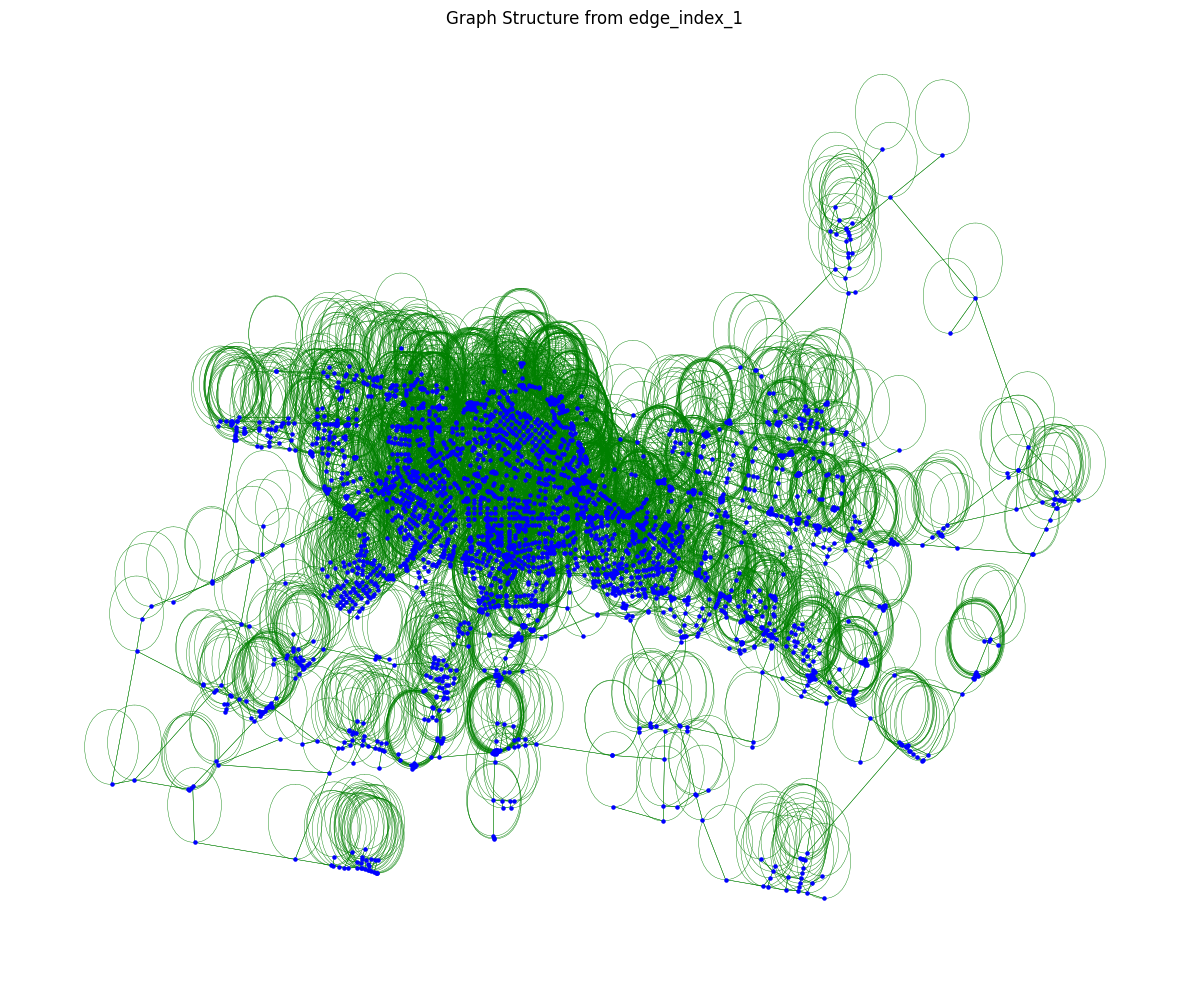

In [25]:
import networkx as nx

import matplotlib.pyplot as plt

# Create a directed graph from edge_index1
G = nx.DiGraph()
edges = [(edge_index1[0, i].item(), edge_index1[1, i].item()) for i in range(edge_index1.shape[1])]
G.add_edges_from(edges)

# Get positions for nodes using the geometry from nodes_gnn
pos = {i: (row.geometry.x, row.geometry.y) for i, row in nodes_gnn.iterrows()}

# Create figure
plt.figure(figsize=(12, 10))

# Plot the network
nx.draw_networkx(G, pos, 
                 node_size=5,
                 node_color='blue',
                 edge_color='green',
                 width=0.3,
                 arrows=False,
                 with_labels=False)

plt.title('Graph Structure from edge_index_1')
plt.axis('off')
plt.tight_layout()
plt.show()

IMPORTANT STAFF: ATTENTION WEIGHTS ARE: NUMBER EDGES (importance of each neighborhood) + NUMBER NODES (importance of the node itself) - SELF LOOPS (not counting node themself twice), this is in order to not count the self loops twice.
KEEP GOING FROM HERE

### Let's study a given node and its neighbors
Informations flow from source to target along the edges, neighbors that have a role in computing the attention are only those that "flow" into a given node.

In [26]:
# find the node with the most neighbors
degree_dict = dict(G.degree())
max_degree_node = max(degree_dict, key=degree_dict.get)
max_degree = degree_dict[max_degree_node]
print(f"Node with most neighbors: {max_degree_node} with degree {max_degree}")

Node with most neighbors: 342 with degree 10


In [42]:
import seaborn as sns
# Study only one node
node_id = 999
# find nodes that point to node_id
target_mask = edge_index1[1] == node_id
neighbors = edge_index1[0][target_mask].cpu().detach().numpy()

print(f"Node {node_id} has {len(neighbors)} neighbors")
print(f"Neighbors: {neighbors}")

# Get the attention weights for the edges pointing to node_id
attention_weights = attn1[target_mask].cpu().detach().numpy()
attention_weights1 = attention_weights[:, 0]  # Select only one head
attention_weights2 = attention_weights[:, 1]  # Select only one head
print(f"Attention weights for edges pointing to node {node_id}: {attention_weights}")
print(f"Total attention weight: {np.sum(attention_weights)}") #2 heads so should be 2

Node 999 has 3 neighbors
Neighbors: [435 952 999]
Attention weights for edges pointing to node 999: [[0.0033719  0.3799404  0.00352739 0.6866095 ]
 [0.08291239 0.37648246 0.10222134 0.23945881]
 [0.91371566 0.24357717 0.8942513  0.0739316 ]]
Total attention weight: 4.0


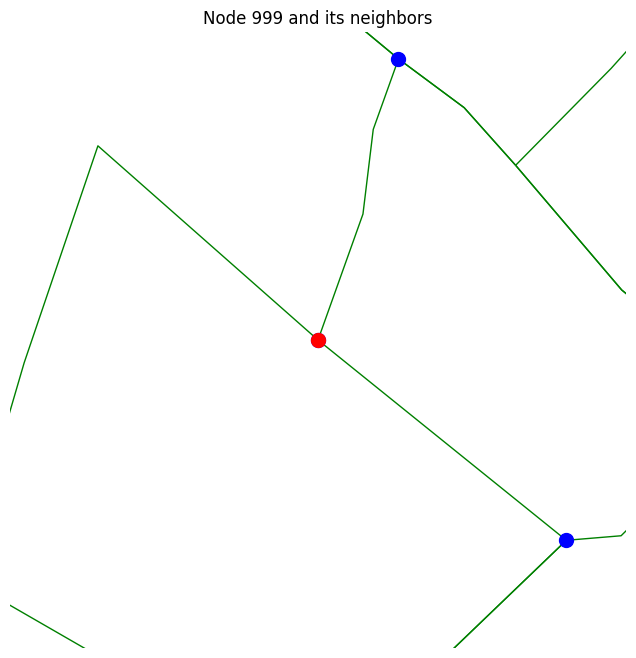

In [43]:
# plot selected node
f, ax = plt.subplots(figsize=(8,8))
ax.scatter(nodes_gnn.x[node_id], nodes_gnn.y[node_id], color='red', s=100, label='Selected Node', zorder=3)
ax.scatter(nodes_gnn.x[neighbors], nodes_gnn.y[neighbors], color='blue', s=100, label='Neighbors', zorder=2)
edges_gnn.plot(ax= ax, linewidth= 1, edgecolor= 'green', zorder=1)

#set xlim and ylim around the selected node
zoom = 100
ax.set_xlim(nodes_gnn.x[node_id] - zoom, nodes_gnn.x[node_id] + zoom)
ax.set_ylim(nodes_gnn.y[node_id] - zoom, nodes_gnn.y[node_id] + zoom)
ax.set_title(f"Node {node_id} and its neighbors")
ax.set_axis_off()

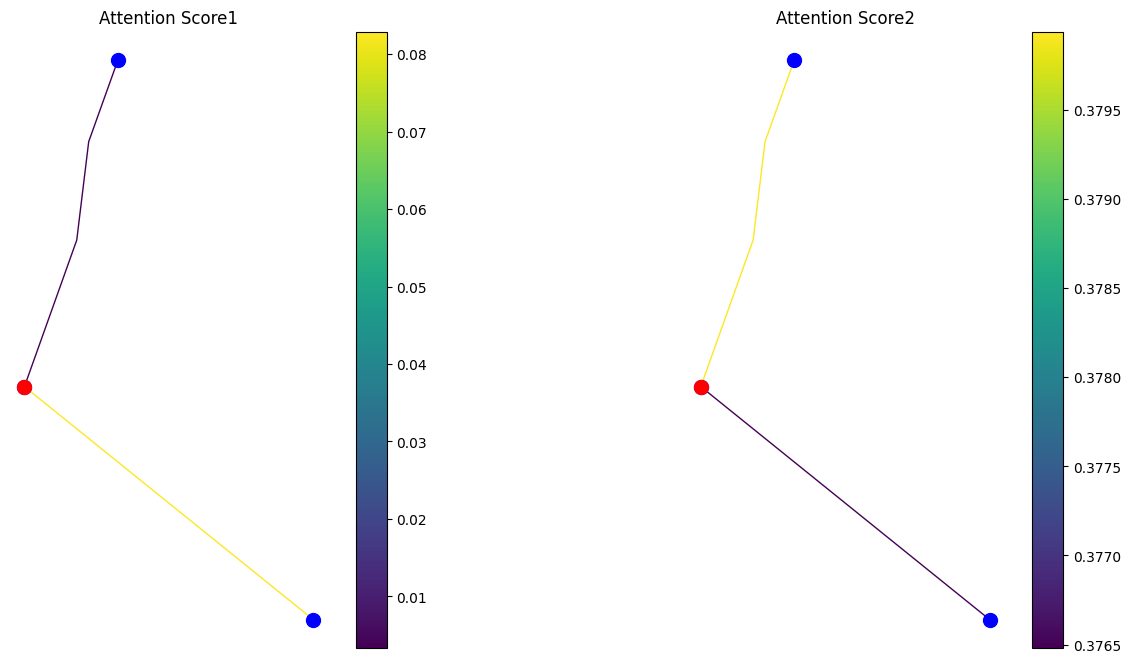

In [44]:
edge_mask = edges_gnn['v'] == nodes_gnn['osmid'][node_id]
edges = edges_gnn[edge_mask]
edges = edges.reset_index(drop=True)
edges['Attention Score1'] = attention_weights1[0:len(edges)]
edges['Attention Score2'] = attention_weights2[0:len(edges)]



#plot 
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8))
edges.plot(ax=ax1, column='Attention Score1', cmap='viridis', legend=True, linewidth=1)
ax1.scatter(nodes_gnn.x[node_id], nodes_gnn.y[node_id], color='red', s=100, label='Selected Node', zorder=3)
ax1.scatter(nodes_gnn.x[neighbors], nodes_gnn.y[neighbors], color='blue', s=100, label='Neighbors', zorder=2)
ax1.set_title('Attention Score1')
ax1.set_axis_off()

edges.plot(ax=ax2, column='Attention Score2', cmap='viridis', legend=True, linewidth=1)
ax2.scatter(nodes_gnn.x[node_id], nodes_gnn.y[node_id], color='red', s=100, label='Selected Node', zorder=3)
ax2.scatter(nodes_gnn.x[neighbors], nodes_gnn.y[neighbors], color='blue', s=100, label='Neighbors', zorder=2)
ax2.set_title('Attention Score2')
ax2.set_axis_off()


An idea could be that since the "traffic speed" is computed considering the betwenness centrality of a node, then the attention weights are computed considering if a neighbor has to "flow" into the given node or not.

### Showing most important neighbors
I want to highlight only the high attention connections, in order to see if there are patterns in the attention weights.
1. Select a threshold
2. Select the edges that are above the threshold


In [114]:
# Threshold attention weights
threshold = 0.5
mask = attn1 > threshold
# Get the edges that have attention weights above the threshold
filtered_att = attn1[mask]

# Get the indices of the edges that have attention weights above the threshold
indices = torch.nonzero(mask, as_tuple=True)[0]
# Get the edges that have attention weights above the threshold
filtered_edges = edge_index1[:, indices]
filtered_edges = filtered_edges.cpu().detach().numpy()


filtered_att.shape

torch.Size([6926])

In [90]:
edges_gnn.columns

Index(['u', 'v', 'key', 'osmid', 'oneway', 'reversed', 'length', 'bridge',
       'speed_kph', 'travel_time', 'junction', 'tunnel', 'access', 'edge_bc',
       'traffic_lights', 'traffic_center', 'traffic_speed', 'traffic_time',
       'geometry'],
      dtype='object')

In [115]:
# translate node index to osmid
filtered_edges_osmid = []
for i in range(filtered_edges.shape[1]):
    filtered_edges_osmid.append([nodes_gnn['osmid'][filtered_edges[0][i]], nodes_gnn['osmid'][filtered_edges[1][i]]])

filtered_edges_osmid = pd.DataFrame(filtered_edges_osmid, columns=['u', 'v'])
filtered_edges_osmid.shape
filtered_edges_osmid['Attention Score'] = filtered_att.cpu().detach().numpy()

In [116]:
# self attention, find the self loops
self_loops = []
for i in range(filtered_edges.shape[1]):
    if filtered_edges[0][i] == filtered_edges[1][i]:
        self_loops.append(filtered_edges_osmid.iloc[i])
self_loops = pd.DataFrame(self_loops, columns=['u', 'v'])
self_loops.shape

filtered_edges_osmid = filtered_edges_osmid[~filtered_edges_osmid.isin(self_loops)].dropna()


In [117]:
#plot the nodes connected by the filtered edges
nodes = set(filtered_edges[0].tolist() + filtered_edges[1].tolist())

# Select nodes_gnn corresponding to nodes
nodes_gnn_filtered = nodes_gnn[nodes_gnn.index.isin(nodes)]
print(f"Number of filtered nodes: {len(nodes_gnn_filtered)}")

#find the edges by matching the u and v columns in edges_gnn with filtered_edges
edges_gnn_filtered = edges_gnn.merge(filtered_edges_osmid, on=['u', 'v'], how='inner')
print(f"Number of filtered edges: {len(edges_gnn_filtered)}")


# assign attention weights to the filtered edges
edges_gnn_filtered['Attention Score1'] = filtered_edges_osmid['Attention Score']

Number of filtered nodes: 2773
Number of filtered edges: 4559


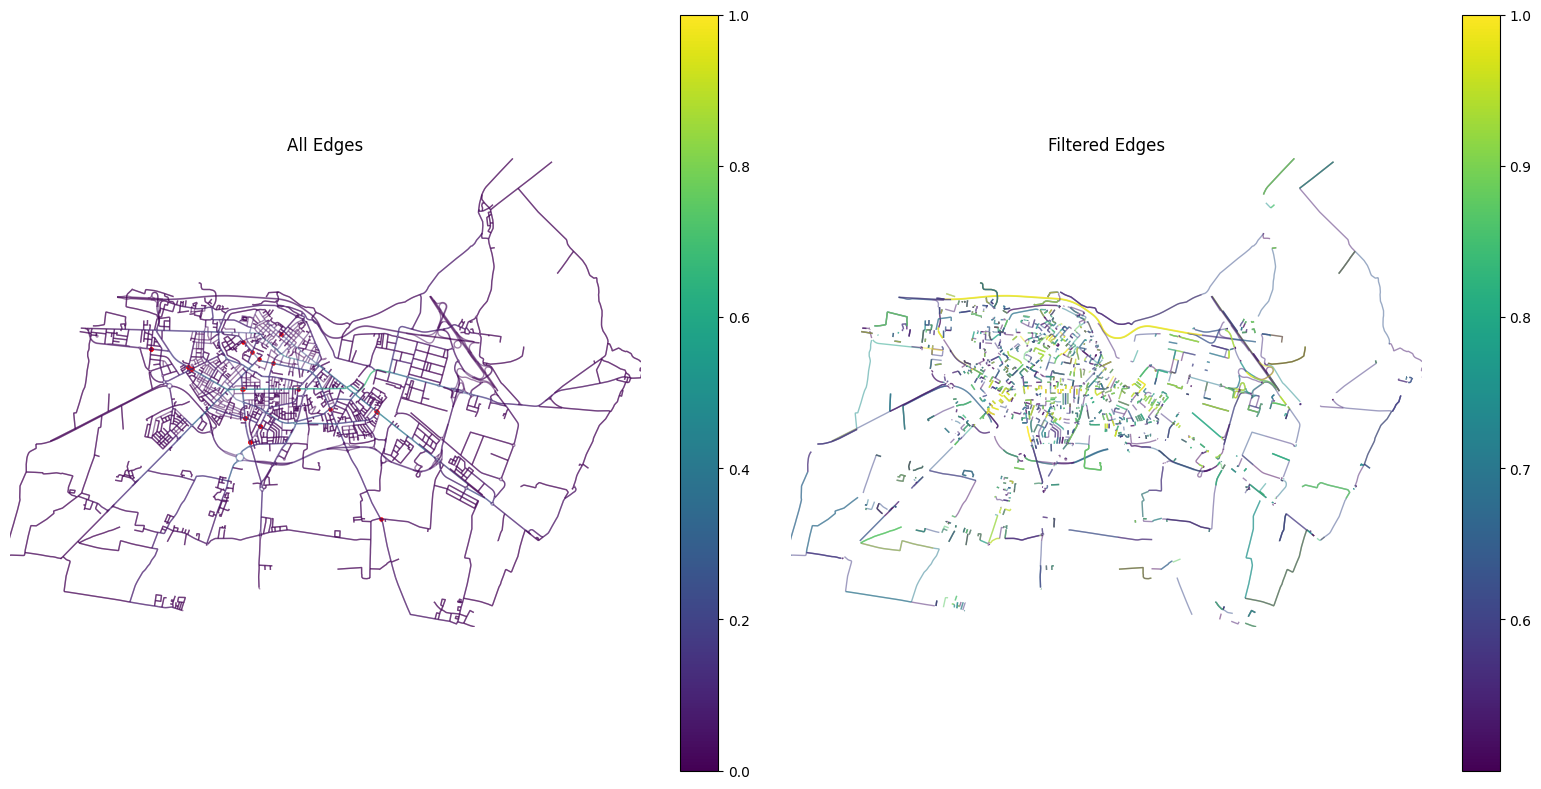

In [130]:
# Visualization of filtered edges vs all edges
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot all edges
edges_gnn.plot(ax=ax1, linewidth=1, alpha=0.5, column = 'edge_bc', cmap='viridis', legend=True)
nodes_gnn[nodes_gnn['traffic_lights'] == 1].plot(ax=ax1, color='red', markersize=5)
ax1.set_title('All Edges')
ax1.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax1.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax1.set_axis_off()

# Plot filtered edges
edges_gnn_filtered.plot(ax=ax2, linewidth=1, alpha=0.5, column='Attention Score1', cmap='viridis', legend=True)
#nodes_gnn.plot(ax=ax2, color='blue', markersize=2)
ax2.set_title('Filtered Edges')
ax2.set_xlim(nodes_gnn.x.min(), nodes_gnn.x.max())
ax2.set_ylim(nodes_gnn.y.min(), nodes_gnn.y.max())
ax2.set_axis_off()
plt.tight_layout()
plt.show()

we can see from this inspection that the GAT learns to focus on betweeness centrality, presence of traffic lights, and for sure also learns that the highway is faster.

I think this is promising, we will also compare with a completely new dataset, and we will see if the attention weights are still similar. but for now let's move to the transformer model.

## Graph Transformer
### As for the previous notebook, I will focus on GPS model.